In [1]:
import pandas as pd
import numpy as np
# from data_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv('../datasets/csgo.csv')
data

,map,day,month,year,date,wait_time_s,match_time_s,team_a_rounds,team_b_rounds,ping,kills,assists,deaths,mvps,hs_percent,points,result
0,Mirage,3.0,8.0,2018.0,3/8/2018,327.0,2906.0,16.0,13.0,215.0,17.0,2.0,21.0,2.0,5.0,45.0,Win
1,Mirage,2.0,8.0,2018.0,2/8/2018,336.0,2592.0,16.0,11.0,199.0,13.0,4.0,24.0,2.0,0.0,40.0,Lost
2,Mirage,31.0,7.0,2018.0,31/7/2018,414.0,2731.0,16.0,14.0,85.0,15.0,3.0,18.0,3.0,26.0,37.0,Win
3,Mirage,31.0,7.0,2018.0,31/7/2018,317.0,2379.0,11.0,16.0,93.0,12.0,2.0,15.0,2.0,16.0,30.0,Lost
4,Mirage,30.0,7.0,2018.0,30/7/2018,340.0,3467.0,15.0,15.0,94.0,33.0,5.0,20.0,5.0,30.0,83.0,Tie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,Dust II,23.0,7.0,2015.0,23/7/2015,2.0,1573.0,16.0,4.0,46.0,12.0,2.0,20.0,0.0,16.0,26.0,Lost
1129,Dust II,23.0,7.0,2015.0,23/7/2015,29.0,2126.0,16.0,8.0,41.0,19.0,6.0,21.0,2.0,31.0,51.0,Lost
1130,Dust II,23.0,7.0,2015.0,23/7/2015,10.0,2555.0,11.0,16.0,17.0,9.0,3.0,20.0,2.0,55.0,30.0,Lost
1131,Dust II,23.0,7.0,2015.0,23/7/2015,9.0,2293.0,8.0,16.0,20.0,11.0,4.0,20.0,1.0,27.0,31.0,Lost


In [3]:
# profile = ProfileReport(data, title = 'CSGO report')
# profile.to_file("CSGO.html")


## 1/ Classification

In [4]:
def value_classifi(x):
    if x == 'Win':
        return 1
    elif x == 'Lost':
        return 0
    else:
        return 2

In [5]:
target = data['result'].apply(value_classifi)
x = data.drop(columns= ['team_a_rounds','team_b_rounds','result','date'])
x = pd.get_dummies(x, columns= ['map'],dtype=int)
y = target


In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size= 0.2,
    random_state= 1009,
    stratify= y
)
print(x_train.dtypes)


day                float64
month              float64
year               float64
wait_time_s        float64
match_time_s       float64
ping               float64
kills              float64
assists            float64
deaths             float64
mvps               float64
hs_percent         float64
points             float64
map_Austria          int64
map_Cache            int64
map_Canals           int64
map_Cobblestone      int64
map_Dust II          int64
map_Inferno          int64
map_Italy            int64
map_Mirage           int64
map_Nuke             int64
map_Overpass         int64
dtype: object


In [7]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
model = RandomForestClassifier(
        n_estimators=500,
        random_state=42
)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [9]:
y_predict = model.predict(x_test)
for i, j in zip(y_predict, y_test):
    print("Prediction_value : {} and Actual_value : {}".format(i,j))

Prediction_value : 1 and Actual_value : 1
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 1
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 1
Prediction_value : 1 and Actual_value : 1
Prediction_value : 1 and Actual_value : 1
Prediction_value : 0 and Actual_value : 0
Prediction_value : 1 and Actual_value : 1
Prediction_value : 1 and Actual_value : 1
Prediction_value : 2 and Actual_value : 2
Prediction_value : 1 and Actual_value : 1
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 0
Prediction_value : 1 and Actual_value : 1
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 0
Prediction_value : 0 and Actual_value : 1
Prediction_value : 1 and Actual_value : 1
Prediction_value : 1 and Actual_value : 1
Prediction_value : 0 and Actual_va

In [10]:
from sklearn.metrics import  classification_report, ConfusionMatrixDisplay
print(data["result"].value_counts())

print(y.value_counts())

print(np.unique(y_predict, return_counts=True))

print(classification_report(
    y_test,
    y_predict,
    target_names=["Lost","Win","Draw"]
))

result
Lost    560
Win     488
Tie      85
Name: count, dtype: int64
result
0    560
1    488
2     85
Name: count, dtype: int64
(array([0, 1, 2]), array([137,  85,   5]))
              precision    recall  f1-score   support

        Lost       0.72      0.88      0.80       112
         Win       0.85      0.73      0.79        98
        Draw       0.20      0.06      0.09        17

    accuracy                           0.76       227
   macro avg       0.59      0.56      0.56       227
weighted avg       0.74      0.76      0.74       227



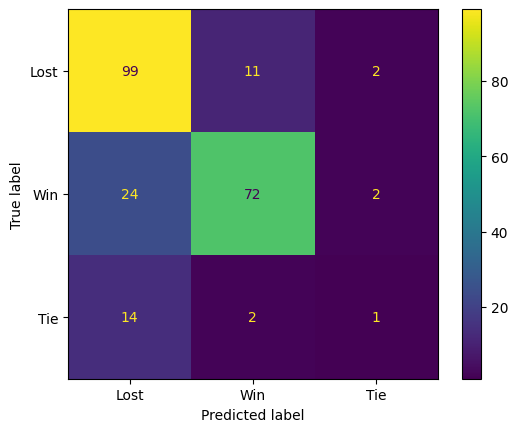

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_predict,
    display_labels=["Lost", "Win", "Tie"]
)

## 2/Regression

In [12]:
data

,map,day,month,year,date,wait_time_s,match_time_s,team_a_rounds,team_b_rounds,ping,kills,assists,deaths,mvps,hs_percent,points,result
0,Mirage,3.0,8.0,2018.0,3/8/2018,327.0,2906.0,16.0,13.0,215.0,17.0,2.0,21.0,2.0,5.0,45.0,Win
1,Mirage,2.0,8.0,2018.0,2/8/2018,336.0,2592.0,16.0,11.0,199.0,13.0,4.0,24.0,2.0,0.0,40.0,Lost
2,Mirage,31.0,7.0,2018.0,31/7/2018,414.0,2731.0,16.0,14.0,85.0,15.0,3.0,18.0,3.0,26.0,37.0,Win
3,Mirage,31.0,7.0,2018.0,31/7/2018,317.0,2379.0,11.0,16.0,93.0,12.0,2.0,15.0,2.0,16.0,30.0,Lost
4,Mirage,30.0,7.0,2018.0,30/7/2018,340.0,3467.0,15.0,15.0,94.0,33.0,5.0,20.0,5.0,30.0,83.0,Tie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,Dust II,23.0,7.0,2015.0,23/7/2015,2.0,1573.0,16.0,4.0,46.0,12.0,2.0,20.0,0.0,16.0,26.0,Lost
1129,Dust II,23.0,7.0,2015.0,23/7/2015,29.0,2126.0,16.0,8.0,41.0,19.0,6.0,21.0,2.0,31.0,51.0,Lost
1130,Dust II,23.0,7.0,2015.0,23/7/2015,10.0,2555.0,11.0,16.0,17.0,9.0,3.0,20.0,2.0,55.0,30.0,Lost
1131,Dust II,23.0,7.0,2015.0,23/7/2015,9.0,2293.0,8.0,16.0,20.0,11.0,4.0,20.0,1.0,27.0,31.0,Lost


In [13]:
target = 'points'
x = data.drop(columns= ['date','team_a_rounds','team_b_rounds','result',target])
x = pd.get_dummies(x, columns= ['map'], dtype =int)
y = data[target]
print(x)

       day  month    year  wait_time_s  match_time_s   ping  kills  assists  \
0      3.0    8.0  2018.0        327.0        2906.0  215.0   17.0      2.0   
1      2.0    8.0  2018.0        336.0        2592.0  199.0   13.0      4.0   
2     31.0    7.0  2018.0        414.0        2731.0   85.0   15.0      3.0   
3     31.0    7.0  2018.0        317.0        2379.0   93.0   12.0      2.0   
4     30.0    7.0  2018.0        340.0        3467.0   94.0   33.0      5.0   
...    ...    ...     ...          ...           ...    ...    ...      ...   
1128  23.0    7.0  2015.0          2.0        1573.0   46.0   12.0      2.0   
1129  23.0    7.0  2015.0         29.0        2126.0   41.0   19.0      6.0   
1130  23.0    7.0  2015.0         10.0        2555.0   17.0    9.0      3.0   
1131  23.0    7.0  2015.0          9.0        2293.0   20.0   11.0      4.0   
1132  23.0    7.0  2015.0          3.0        1858.0   16.0    6.0      3.0   

      deaths  mvps  ...  map_Austria  map_Cache  ma

In [15]:
x_train,x_test, y_train, y_test = train_test_split(
    x, y,
    test_size= 0.2,
    random_state= 1009
)

In [16]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
#model = SVR()
model = LinearRegression() ## Tot nhat
#model = RandomForestRegressor()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0.16,-0.18,-1.1 ,..., 0.28,-0.13, 0.11]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,39.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,19
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](21,)","[48.87,45.49,39.18,...,13.21, 0. , 0. ]"


In [32]:
y_predict = model.predict(x_test)
for i,j in zip(y_test, y_predict):
    print("Actual : {} and Predict: {}".format(i,j))

Actual : 60.0 and Predict: 58.8112562198434
Actual : 46.0 and Predict: 45.59022778481289
Actual : 68.0 and Predict: 64.61145297175442
Actual : 51.0 and Predict: 46.20385851757584
Actual : 39.0 and Predict: 40.85253340367613
Actual : 59.0 and Predict: 61.016838028104644
Actual : 67.0 and Predict: 68.51469293043856
Actual : 62.0 and Predict: 69.76686533513947
Actual : 22.0 and Predict: 20.96140913726256
Actual : 46.0 and Predict: 47.724243322758156
Actual : 69.0 and Predict: 69.01041840114587
Actual : 50.0 and Predict: 52.7595104882341
Actual : 53.0 and Predict: 44.24730389653406
Actual : 51.0 and Predict: 51.462929451706664
Actual : 48.0 and Predict: 44.976407344938806
Actual : 50.0 and Predict: 54.31174742763235
Actual : 39.0 and Predict: 40.54953108738761
Actual : 47.0 and Predict: 52.569588861121204
Actual : 64.0 and Predict: 66.90577958890731
Actual : 49.0 and Predict: 48.702253813459414
Actual : 45.0 and Predict: 43.16106028154495
Actual : 55.0 and Predict: 52.02912191735109
Actual

In [33]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, r2_score
print('MAE : {}'.format(mean_absolute_error(y_test,y_predict)))
print('RMSE : {}'.format(root_mean_squared_error(y_test,y_predict)))
print('COEFFICIENT OF DETERMINATION : {}'.format(r2_score(y_test,y_predict)))

MAE : 2.8816210192673704
RMSE : 3.627192834105524
COEFFICIENT OF DETERMINATION : 0.9449588143580957
